# Motivation — what the judge is asked changes what it answers

One judge (`gpt-5.4`), the three P3–P5 prompt forms, in both tracks. Same
`unified_pairwise` chart data [two_track_figure.ipynb](two_track_figure.ipynb)
reads. Everything the figure says is in the config cell.

In [11]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir() and (p / "output").is_dir()
)
sys.path.insert(0, str(ROOT / "src"))

from novelty_eval.figures.common import PDF_RCPARAMS, chart_data_path, save_figure

In [12]:
# ---- everything the figure says ----------------------------------------------

# Bar groups, left to right: x-axis label -> merge directory under
# output/ablation_sweeps.
GROUPS = {
    "Human+Generated": "merge_vanilla_all_metrics",
    "Human-Only": "merge_hvh_all_metrics",
}

# Bars within a group, left to right: (legend text, panel name, colour).
SERIES = [
    ("Which was judged novel?", "ai_researcher_base", "#f0cda1"),
    ("Which is novel?", "ai_researcher_no_review", "#806291"),
    ("Which was judged more novel?", "ai_researcher_comparative", "#adafc4"),
]

JUDGE = "gpt-5.4"
SETUP, VARIANT, METRIC = "pairwise", "filtered", "pairwise_accuracy_strict"

# 95% bootstrap CI over the instances a run was scored on, drawn as an error bar.
# Not the intervals the merge stored: those are for the delta against the
# reference prompt, and these bars are absolute scores.
SHOW_ERROR_BARS = True
N_RESAMPLES = 10000               # the interval moves by <0.1 points past ~2000
SEED = 42
CI_LABEL = "95% bootstrap CI"     # legend entry for the interval; "" drops it

# Text
XLABEL, YLABEL = "Data Setup", "Accuracy"
VALUE_FMT = "{:.2f}"              # the number printed above a bar
YTICKS = [0, 20, 40, 60, 80, 100]
YTICK_FMT = "{:.0f}"              # how a y-axis number is written
# Poppins is vendored beside this notebook in fonts/ (OFL) and registered in the
# figure cell, so the figure draws the same on a machine that has never seen it.
# It ships Regular/Medium/SemiBold/Bold, which is what lets FONT_WEIGHTS ask for
# a weight between the two extremes — most system sans faces have only 400/700.
FONT = ["Poppins", "Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
FONT_SIZES = {"value": 11, "ytick": 11, "xtick": 11, "legend": 9, "axis": 12}
# Mildly bold throughout: medium (500) everywhere, semibold (600) for the axis
# titles so they stay the heaviest thing on the page.
FONT_WEIGHTS = {"value": "medium", "ytick": "medium", "xtick": "medium",
                "legend": "medium", "axis": "semibold"}
TEXT_COLOR = "#000000"
LEGEND_ROWS = [2, 1]              # entries per centred legend row, top to bottom
LEGEND_Y = [1.00, 0.885]          # top of each legend row, in figure fractions
LEGEND_HANDLE = 1.6               # width of a key, in font sizes — the CI mark's
                                  # |—| spans it, a dot sits in the middle of it

# Geometry, in inches / axis units
FIG_SIZE = (4.95, 3.25)
AXES = [0.155, 0.185, 0.817, 0.508]   # left, bottom, width, height
BAR_WIDTH, BAR_PITCH = 0.253, 0.264   # bar width and centre-to-centre spacing
XPAD = 0.42                           # half-width of a group slot, sets the x-limits
VALUE_PAD = 3.5                       # gap between a bar (or its CI) and its number
AXIS_PAD = {"x": 8, "y": 8}           # gap between an axis title and its ticks
MARKER_SIZE = 9.5                     # legend dot diameter, in points
GRID_COLOR, SPINE_COLOR = "#dfdfdf", "#b1b1b1"
# A hairline in muted ink, with short caps. `halo` is a white pass underneath, so
# the bar reads against the fill it crosses as clearly as against the page.
ERRORBAR = {"color": "#4a4a5c", "lw": 0.9, "capsize": 2.2, "halo": 2.2}

FIGURE = "motivation"             # output/figures/<FIGURE>/<FIGURE>.{pdf,png}
FORMATS = [".pdf", ".png"]

In [13]:
# ---- the numbers --------------------------------------------------------------

PANELS = {
    group: json.loads(chart_data_path(ROOT / "output/ablation_sweeps" / merge_dir,
                                      SETUP, VARIANT).read_text())["panels"]
    for group, merge_dir in GROUPS.items()
}

table = pd.DataFrame(
    {group: [PANELS[group][panel]["ablation_metrics"][JUDGE][METRIC] * 100
             for _, panel, _ in SERIES]
     for group in GROUPS},
    index=[label for label, _, _ in SERIES],
)
print(f"{JUDGE} · {METRIC} · {SETUP}/{VARIANT}\n")
print(table.round(2).to_string())

gpt-5.4 · pairwise_accuracy_strict · pairwise/filtered

                              Human+Generated  Human-Only
Which was judged novel?                 93.51       83.12
Which is novel?                         40.91       75.97
Which was judged more novel?            59.74       80.52


In [14]:
# ---- the error bars -----------------------------------------------------------
# A bar's interval is a bootstrap over the instances that run was scored on, the
# same resampling `retrieval_faceoff_figure.ipynb` draws. The merge's own
# `bootstrap_results` are intervals on the delta against the reference prompt, so
# they cannot be hung on an absolute bar.

import re

from novelty_eval.analysis.artifacts import (
    _extract_instances_path, _extract_raw_outcomes_for_dir)
from novelty_eval.analysis.filtering import (
    _derive_exclude_indices, _load_paper_blocklist)
from novelty_eval.analysis.stats_one_pass import _run_bootstrap_multi

BLOCKED = _load_paper_blocklist()
PAIRWISE_KEYS = ["pairwise_accuracy", "pairwise_accuracy_strict",
                 "pairwise_accuracy_no_ties"]


def pairwise_metrics(correct, tie):
    """The three pairwise accuracies of one run, in the merge's own definitions.

    stats_one_pass only has them as a delta between two runs; a bar here is an
    absolute score, so the same three are written out over one run's instances.
    """
    no_tie = correct[tie < 0.5]
    return np.array([np.mean(correct + 0.5 * tie), np.mean(correct),
                     np.mean(no_tie) if len(no_tie) else 0.0])


def artifact_dir(group, index_key):
    """The run the merge used for one (panel, judge).

    artifacts/ also holds superseded copies — a re-run judge appears twice under
    two timestamps — so the summary the merge wrote is what names the live one.
    """
    summary = (ROOT / "output/ablation_sweeps" / GROUPS[group]
               / "merged_ablation_summary.md").read_text()
    hits = {p for p in re.findall(r"`(output/ablation_sweeps/\S*?/artifacts/[^`]+)`",
                                  summary)
            if Path(p).name.startswith(f"{index_key}-{JUDGE}_")}
    hit, = hits          # one run, or the interval would belong to a different one
    return ROOT / hit


def bootstrap_ci(group, panel, plotted):
    """95% CI in points for one bar, plus the number of instances behind it.

    The assert is the check that the resampled run is the plotted one: the point
    estimate off its own scores.json has to match the number in the chart data,
    filtered to the same blocklist exclusions the merge applied.
    """
    index_key = PANELS[group][panel]["index_key"]
    run = artifact_dir(group, index_key)
    excluded = set(_derive_exclude_indices(_extract_instances_path(run), BLOCKED))
    outcomes = _extract_raw_outcomes_for_dir(run, SETUP, index_key, None)

    correct, tie = outcomes["_pairwise_is_correct"], outcomes["_pairwise_is_tie"]
    pids = sorted(p for p in correct if p not in excluded)   # sorted: stable order
    data = (np.array([correct[p] for p in pids]), np.array([tie[p] for p in pids]))

    point = dict(zip(PAIRWISE_KEYS, pairwise_metrics(*data)))
    assert abs(point[METRIC] * 100 - plotted) < 0.05, \
        f"{run.name}: scores say {point[METRIC] * 100:.2f}, the chart data {plotted:.2f}"

    boot = _run_bootstrap_multi(data, pairwise_metrics, PAIRWISE_KEYS,
                                n_resamples=N_RESAMPLES, random_state=SEED,
                                label=run.name, _logger=None)[METRIC]
    return boot["ci_low"] * 100, boot["ci_high"] * 100, len(pids)


if SHOW_ERROR_BARS:
    cis = {(group, label): bootstrap_ci(group, panel, table.loc[label, group])
           for group in GROUPS for label, panel, _ in SERIES}
    ci_low = pd.DataFrame({g: [cis[g, r][0] for r in table.index] for g in GROUPS},
                          index=table.index)
    ci_high = pd.DataFrame({g: [cis[g, r][1] for r in table.index] for g in GROUPS},
                           index=table.index)
    print(f"{N_RESAMPLES} resamples, support "
          f"{sorted({n for *_, n in cis.values()})}\n")
    print(pd.concat({"value": table, "ci_low": ci_low, "ci_high": ci_high},
                    axis=1).round(2).to_string())

10000 resamples, support [154]

                                       value                     ci_low                    ci_high           
                             Human+Generated Human-Only Human+Generated Human-Only Human+Generated Human-Only
Which was judged novel?                93.51      83.12           88.96      76.62           96.75      88.31
Which is novel?                        40.91      75.97           33.12      68.83           48.70      82.47
Which was judged more novel?           59.74      80.52           51.95      74.03           67.53      86.36


output/figures/motivation/motivation.pdf
output/figures/motivation/motivation.png


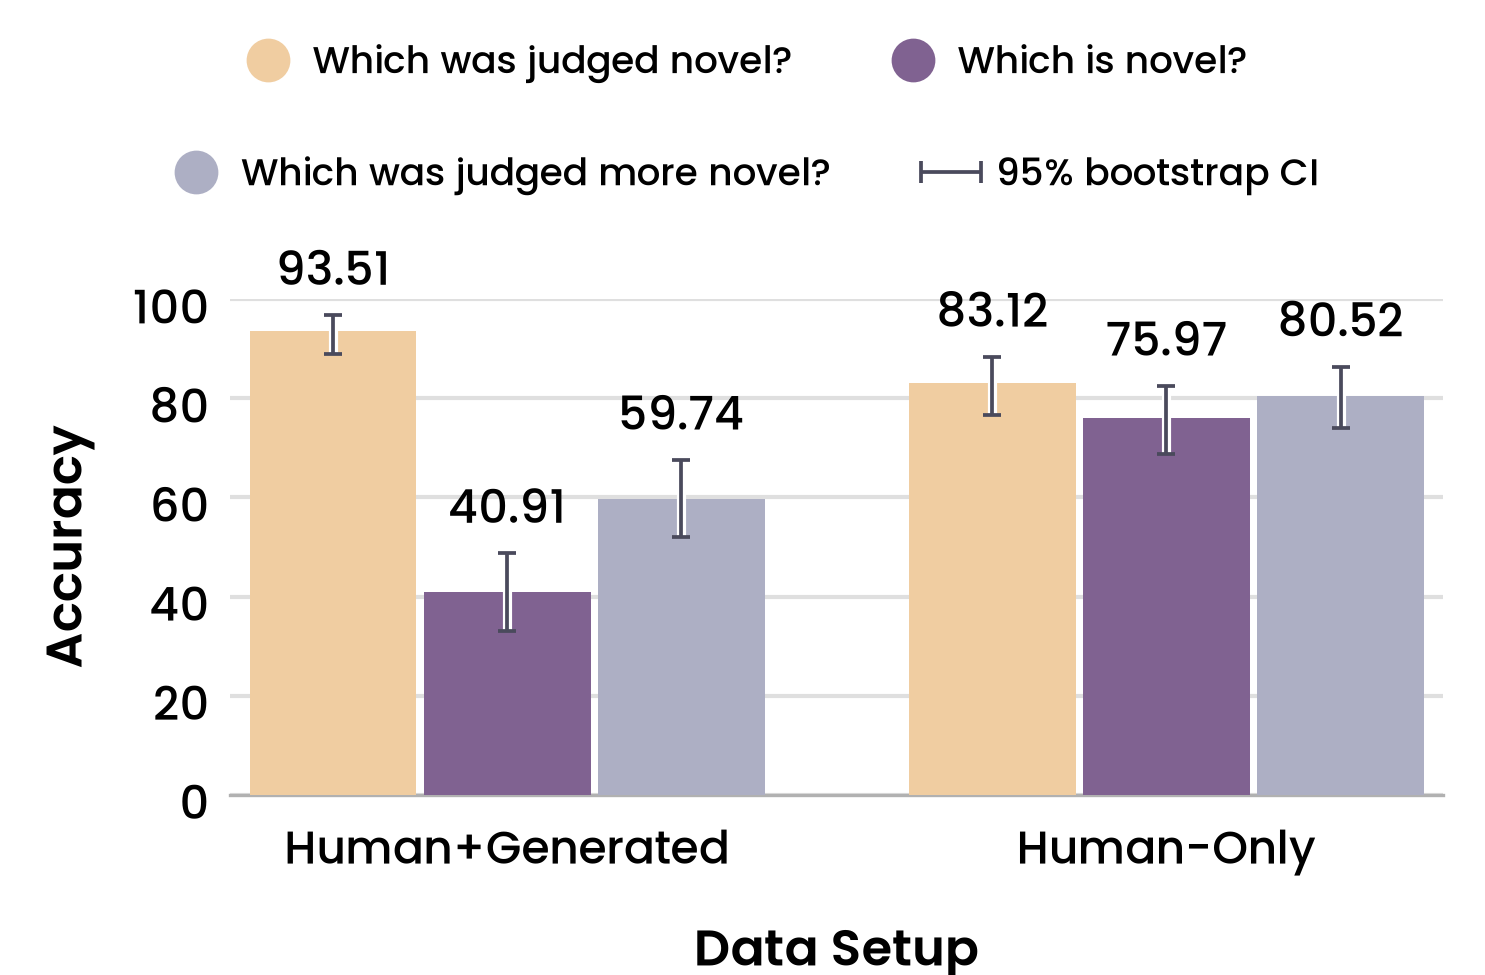

In [15]:
# ---- the figure ---------------------------------------------------------------
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

# The vendored faces, so FONT resolves to them whether or not they are installed
# on this machine. Registering a face twice is harmless, so re-running is safe.
for face in sorted((ROOT / "src/novelty_eval/figures/fonts").glob("*.ttf")):
    fm.fontManager.addfont(str(face))

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": FONT,
                     "text.color": TEXT_COLOR, **PDF_RCPARAMS})


def draw_interval(ax, xs, values, low, high):
    """The CI bars for one series: a white pass, then the hairline over it.

    The halo is drawn without caps — a capped white pass puts a block inside the
    bar, which reads as a notch in the fill rather than as an outline.
    """
    err = np.vstack([values - low, high - values])   # asymmetric: an arm each
    for lw, colour, cap, z in ((ERRORBAR["halo"], "white", 0, 3.5),
                               (ERRORBAR["lw"], ERRORBAR["color"],
                                ERRORBAR["capsize"], 4)):
        ax.errorbar(xs, values, yerr=err, fmt="none", ecolor=colour, elinewidth=lw,
                    capsize=cap, capthick=lw, zorder=z)


class IntervalKey(HandlerBase):
    """The CI key, lying down: |—|, a rule with a cap at each end.

    Built from ERRORBAR, the same entry the bars' intervals are drawn from, so
    the key follows any restyling of them. matplotlib's own errorbar key would
    stand the mark upright, since the intervals are on y.
    """

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        mid, cap = height / 2, height * 0.42
        arts = [Line2D([0, width], [mid, mid]),
                *(Line2D([x, x], [mid - cap, mid + cap]) for x in (0, width))]
        for a in arts:
            a.set(color=ERRORBAR["color"], lw=ERRORBAR["lw"], solid_capstyle="butt")
            a.set_transform(trans)
        return arts


fig = plt.figure(figsize=FIG_SIZE, facecolor="white")
ax = fig.add_axes(AXES)
x = np.arange(len(GROUPS))
for i, (label, _panel, colour) in enumerate(SERIES):
    offset = (i - (len(SERIES) - 1) / 2) * BAR_PITCH
    values = table.loc[label]
    ax.bar(x + offset, values, width=BAR_WIDTH, color=colour, zorder=3)

    # The number goes above the interval, never on it, so `tops` is whatever the
    # bar actually reaches.
    tops = values
    if SHOW_ERROR_BARS:
        draw_interval(ax, x + offset, values, ci_low.loc[label], ci_high.loc[label])
        tops = ci_high.loc[label]
    for xi, value, top in zip(x + offset, values, tops):
        ax.annotate(VALUE_FMT.format(value), (xi, top), textcoords="offset points",
                    xytext=(0, VALUE_PAD), ha="center", va="bottom",
                    fontsize=FONT_SIZES["value"], fontweight=FONT_WEIGHTS["value"],
                    color=TEXT_COLOR)

ax.set_xlim(-XPAD, len(GROUPS) - 1 + XPAD)
ax.set_ylim(0, max(YTICKS))
ax.set_xticks(x, list(GROUPS), fontsize=FONT_SIZES["xtick"],
              fontweight=FONT_WEIGHTS["xtick"])
ax.set_yticks(YTICKS, [YTICK_FMT.format(t) for t in YTICKS],
              fontsize=FONT_SIZES["ytick"], fontweight=FONT_WEIGHTS["ytick"])
ax.set_xlabel(XLABEL, fontsize=FONT_SIZES["axis"], fontweight=FONT_WEIGHTS["axis"],
              labelpad=AXIS_PAD["x"])
ax.set_ylabel(YLABEL, fontsize=FONT_SIZES["axis"], fontweight=FONT_WEIGHTS["axis"],
              labelpad=AXIS_PAD["y"])
ax.yaxis.grid(True, color=GRID_COLOR, lw=1.0)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(SPINE_COLOR)
ax.tick_params(length=0, pad=5, labelcolor=TEXT_COLOR)

handles = [Line2D([], [], marker="o", ls="", markersize=MARKER_SIZE, color=colour,
                  label=label) for label, _panel, colour in SERIES]
handler_map = {}
if SHOW_ERROR_BARS and CI_LABEL:
    ci_key = Line2D([], [], label=CI_LABEL)
    handles.append(ci_key)
    handler_map[ci_key] = IntervalKey()

# one centred legend per row, so a row of entries is centred on the figure
rows = list(LEGEND_ROWS)
rows[-1] += len(handles) - sum(rows)      # a CI key rides on the last row
at = 0
for n, y in zip(rows, LEGEND_Y):
    fig.legend(handles=handles[at:at + n], loc="upper center",
               bbox_to_anchor=(0.5, y), ncol=n, frameon=False,
               handler_map=handler_map, handlelength=LEGEND_HANDLE,
               prop={"size": FONT_SIZES["legend"], "weight": FONT_WEIGHTS["legend"]},
               labelcolor=TEXT_COLOR, handletextpad=0.4, columnspacing=2.4)
    at += n

written = save_figure(fig, ROOT / "output/figures" / FIGURE / (FIGURE + FORMATS[0]),
                      formats=FORMATS[1:])
print(*[p.relative_to(ROOT) for p in written], sep="\n")
display(Image(filename=str(next(p for p in written if p.suffix == ".png"))))